# LSI31003 Machine Learning in Molecular Biology
## Peptide classification group project

### Introduction:
In Assignment 3, you learned how pretrained transformer models could be used to learn embeddings for short peptide sequences, and how those embeddings could then be further used in downstream machine learning tasks. In assignment 3 we built a classifier to predict whether a given short peptide was of antimicrobial origin (AMP) vs non-Antimicrobial (nonAMP), based on the information contained within its sequence alone.

However, short peptide sequences have also other important functionality in living organisms than just Antimicrobial effects. In this group assignment, you will investigate peptides with multiple biological functionalities. 

Dataset comes from a curated short peptide collection described in (Xiao, B. *et al.*): **A comprehensive dataset of therapeutic peptides on multi-function property and structure information** (https://doi.org/10.1038/s41597-025-05528-1). Read the paper to find further details on how the peptides are classified (main and subcategories), as well as descriptions for the peptide metadata table.

For this task, we have calculated the ESM-2 embeddings for you in advance. All performed preprocessing steps are described in Peptide_project_preprocessing.ipynb. Furthermore, there is a second set of embeddings that is further derived from ESM-2 embeddings using supervised learning methods (known labels) with a deep learning framework (with combination of autoencoder-like reproducibility loss and prediction accuracy for the target label vector). You can use this set of embeddings as well, but if you are familiar with deep learning libraries such as pytorch and tensorflow, it's higly recommended that you try to learn suitable optimized embeddings yourself (but this is not a necessity)! The raw ESM-2 embeddings might also work on their own, but it's up to you to decide/ try out.

### Your task:
Your task is to built a classifier that predicts the peptide classes with as good accuracy as possible, mainly using the embedding representations as inputs (feel free to try other feature engineering methods as well if you like!). Apply dimensionsionality reduction methods if deemed appropriate. You should first make the classifier for the 15 main categories. After that, you can also try to predict the subcategories within each main peptide category. You should do model selection and show performance with confusion matrix visualizations and/or other general accuracy metrics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# your library imports

In [2]:
# peptides with available metadata
meta = pd.read_csv("./data/Peptide_Metadata.csv", index_col = 0)
print(f"{meta.shape[0]} total peptides.")
meta.head(5)

17265 total peptides.


,Function,Label encoding,Sequence,Source,Is_natural_peptide,HELM notation,N-terminal modification,C-terminal modification,Post translation modifications,Reference
ID,,,,,,,,,,
100004,"Antimicrobial|Antibacterial|Anti-gram+,Antimic...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",AAAAAAAAAAGIGKFLHSAKKFGKAFVGEIMNS,Human,True,PEPTIDE1{[ac].A.A.A.A.A.A.A.A.A.A.G.I.G.K.F.L....,NaN,NaN,NaN,"Antimicrob Agents Chemother, 1992, 36, 313;PMI..."
100007,"Antimicrobial|Antibacterial|Anti-gram+,Antimic...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",AAAAAAAIKMLMDLVNERIMALNKKAKK,virus (Bovine papular stomatitis virus)|Bovine...,True,PEPTIDE1{[ac].A.A.A.A.A.A.A.I.K.M.L.M.D.L.V.N....,NaN,NaN,NaN,"PLoS One, 2012, 7, e45848;PMID: 23029273"
100013,"Antimicrobial|Antibacterial|Anti-gram+,Antimic...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",AAAAGSCVWGAVNYTSDCAAECKRRGYKGGHCGSFANVNCWCET,ND,True,PEPTIDE1{[ac].A.A.A.A.G.S.C.V.W.G.A.V.N.Y.T.S....,NaN,NaN,NaN,"Biochemistry, 2001, 40, 11995;PMID: 11580275"
100014,"Antimicrobial|Antibacterial|Anti-gram+,Antimic...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",AAAAGSCVWGAVNYTSDCAAECKRRGYKGGHCGSFANVNCWCRT,ND,True,PEPTIDE1{[ac].A.A.A.A.G.S.C.V.W.G.A.V.N.Y.T.S....,NaN,NaN,NaN,"Biochemistry, 2001, 40, 11995;PMID: 11580275"
100015,"Antimicrobial|Antibacterial|Anti-gram+,Antimic...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",AAAAGSCVWGAVNYTSDCAAECLLRGYKGGHCGSFANVNCWCET,ND,True,PEPTIDE1{[ac].A.A.A.A.G.S.C.V.W.G.A.V.N.Y.T.S....,NaN,NaN,NaN,"Biochemistry, 2001, 40, 11995;PMID: 11580275"


In [3]:
# Embeddings from ESM2-model (same pipeline as in Assignment 3)
embeddings_esm = pd.read_csv("./data/Embeddings_Esm2.csv", index_col = 0)
print(f"{embeddings_esm.shape[1]} dimensional peptide embeddings from ESM-2 model")
embeddings_esm.head()

1280 dimensional peptide embeddings from ESM-2 model


,0,1,2,3,4,5,6,7,8,9,...,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279
ID,,,,,,,,,,,,,,,,,,,,,
100004,-0.002897,0.032261,-0.061632,-0.012294,0.083954,-0.027361,-0.064955,0.041762,-0.006667,-0.117269,...,0.030947,-0.058636,-0.084253,0.144039,0.056908,0.058979,0.020752,0.068330,-0.123524,0.092439
100007,-0.021438,-0.036954,-0.018984,-0.015381,0.001480,-0.057479,-0.045701,0.061801,0.001520,-0.123927,...,0.036371,-0.038882,-0.012545,0.093841,0.050679,0.047878,0.106075,-0.061094,-0.028786,0.008304
100013,-0.010459,-0.011805,0.022508,0.043741,0.000519,0.033871,0.051326,-0.015819,0.054000,0.081105,...,0.080855,0.000629,0.045531,-0.001710,-0.054935,-0.035005,0.033414,-0.098053,-0.008366,0.099628
100014,-0.029972,-0.022473,0.018484,0.042649,-0.010375,0.047744,0.059621,-0.011444,0.034726,0.089829,...,0.074273,-0.021156,0.043835,0.022560,-0.047037,-0.015590,0.029909,-0.103113,0.008463,0.077277
100015,-0.011639,-0.005451,0.037088,0.048091,0.013870,0.033050,0.023372,0.010481,0.066343,0.064727,...,0.087427,0.014022,0.045259,-0.006255,-0.051198,-0.025632,0.039032,-0.091726,-0.007044,0.110314


In [4]:
# Mystery embeddings: derivation from ESM-embeddings optimized with deeplearning methods and known labels.
embeddings_finetuned = pd.read_csv("./data/Embeddings_Mysteryengineered.csv", index_col = 0)
print(f"{embeddings_finetuned.shape[1]} dimensional peptide embeddings downstream engineered from ESM-2 model")
embeddings_finetuned.head()

200 dimensional peptide embeddings downstream engineered from ESM-2 model


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
ID,,,,,,,,,,,,,,,,,,,,,
100004,-0.483709,-0.557164,-0.420388,-0.175160,0.793239,0.120372,-0.146778,0.119034,0.344554,0.565946,...,0.154780,-0.338444,-0.211424,0.650465,0.168623,0.403776,0.295616,-0.637571,-0.235686,-0.062087
100007,-0.384557,-0.158466,-0.540723,-0.139707,0.417634,0.441971,-0.197034,0.160257,0.352310,0.503866,...,0.320291,-0.296480,-0.400126,0.744250,0.055119,0.386485,0.189654,-0.393325,-0.190110,-0.113808
100013,-0.444259,0.233969,-0.649846,-0.301525,0.378391,0.652291,0.120221,0.060428,0.113184,0.017043,...,0.378905,-0.317880,-0.147875,0.019434,0.200457,0.386632,0.220315,-0.026951,0.105835,-0.316225
100014,-0.447115,0.242742,-0.640375,-0.313176,0.381286,0.642577,0.129668,0.057654,0.108229,0.009943,...,0.386476,-0.319757,-0.132476,-0.004574,0.210770,0.409565,0.223644,-0.020175,0.093596,-0.305084
100015,-0.435927,0.249961,-0.656335,-0.319148,0.338178,0.657516,0.122982,0.063526,0.093505,0.011224,...,0.391172,-0.316295,-0.174601,0.020248,0.212861,0.350936,0.193509,-0.018062,0.098034,-0.329183


**Labels -table columns:**  
`MAIN_category` one of the main 15 categories defined in the table (or "Multipurpose" if peptide belongs to multiple categories).  
`isSinglepurpose`: True if only 1 main category, False if MAIN_Category = "Multipurpose"  
`other columns`: Other peptide subtypes from the paper, corresponding to `Label encoding` -column of the meta table.

In [5]:
labels = pd.read_csv("./data/Peptide_Targetlabels.csv", index_col = 0)
labels

,MAIN_Category,isSinglepurpose,Analgesic,Angiogenic,Anti-gram+,Anti-gram-,AntiAngiogenesis,AntiBreastcancer,AntiCervicalcancer,AntiColoncancer,...,Growth_regulatory,Immunoactive,Lipid_metabolism,Metabolic_regulatory,Neuropeptide,Opioid,Osteogenic,Quorum_sensing,Thrombolytic,Tumor_homing
ID,,,,,,,,,,,,,,,,,,,,,
100004,Antibacterial,True,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100007,Antibacterial,True,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100013,Multipurpose,False,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100014,Multipurpose,False,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100015,Multipurpose,False,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154636,Antibacterial,True,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
154646,Neuropeptide,True,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
154648,Antimicrobial,True,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [26]:
target_value = "MAIN_Category"

for label in labels.drop(["MAIN_Category", "isSinglepurpose"], axis = 1).columns:
    total = labels[label].sum()
    if total > 17265 * 0.01 and total < 17265 * 0.99:
        print(label, labels[label].sum())

Anti-gram+ 5137
Anti-gram- 4926
AntiHIV 900
Antibacterial 6959
Anticancer 1407
Antifungal 3034
Antimicrobial 5507
Antiparasitic 530
Antiviral 2570
Cell_Communication 659
Drug_delivery 180
Glucose_metabolism 320
Metabolic_regulatory 638
Neuropeptide 1430


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering

embeddings_finetuned_fixed = embeddings_finetuned.dropna()
print(embeddings_finetuned_fixed.shape, embeddings_finetuned.shape)
training_data, testing_data = train_test_split(embeddings_finetuned_fixed, test_size = 0.20, random_state = 24)

n = 8
pca = PCA(n_components = n)
scaler = StandardScaler()

# Normalization
normalized_training = scaler.fit_transform(training_data)
normalized_testing = scaler.transform(testing_data)

# PCA
pca_training = pca.fit_transform(normalized_training)
pca_testing = pca.transform(normalized_testing)

pca_training = pd.DataFrame(index = training_data.index, data = pca_training, columns = [f"Component {i}" for i in range(1, n + 1)])
pca_testing = pd.DataFrame(index = testing_data.index, data = pca_testing, columns = [f"Component {i}" for i in range(1, n + 1)])

#clusterer = KMeans(n_clusters = 12, random_state = 24)
#clusterer.fit(pca_training)

#pca_training["Cluster"] = clusterer.fit_predict(pca_training).astype(str)
#pca_testing["Cluster"] = clusterer.predict(pca_testing).astype(str)

pca_training = pca_training.join(labels[[target_value, "isSinglepurpose"]])
pca_testing = pca_testing.join(labels[[target_value, "isSinglepurpose"]])

print(pca_testing)

(17265, 200) (17265, 200)
        Component 1  Component 2  Component 3  Component 4  Component 5  \
ID                                                                        
127918     9.201510     0.387509    -1.562574     1.599836    -6.220214   
141796    -6.797551     2.744803     6.283359     1.667023    -2.934619   
101166    -1.187782     5.541770     1.592912    -1.536924    -0.120707   
132468     1.564586    -7.395223     5.956193    14.053663    12.994202   
153311    -7.976628    -3.903078     2.537573     9.303873     2.117599   
...             ...          ...          ...          ...          ...   
143970    -7.503616     3.252708     2.566297    -2.401309    -3.405225   
116415    13.088975     0.688916    -5.695449    -0.481632    -1.797367   
140697    -2.221251     6.250686     3.324628    -6.568892     4.264793   
149963    -5.206478     2.250064     1.845035    -5.004160    -1.894417   
111445    -9.413784     5.470463     1.630920    -1.688130    -0.929060   

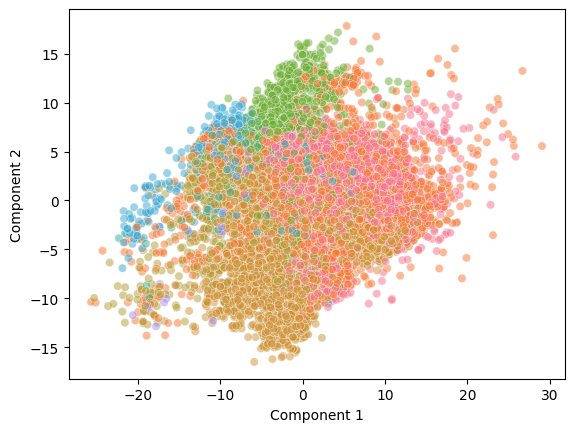

In [9]:
sns.color_palette("rocket", as_cmap=True)

sns.scatterplot(
    x = "Component 1",
    y = "Component 2",
    data = pca_training,
    hue = target_value,
    alpha = 0.5,
    legend = False
)

plt.show()

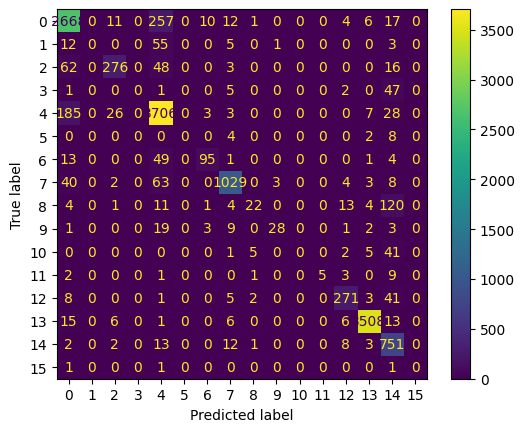

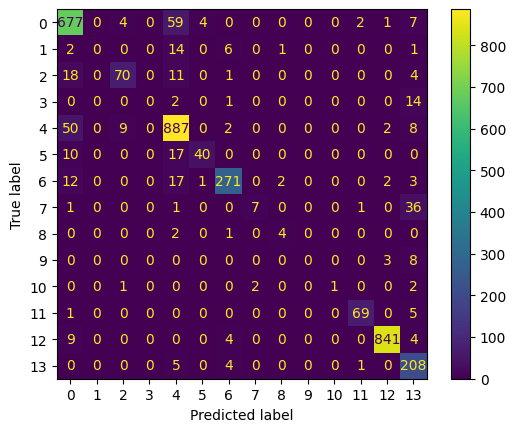

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#rfc_alt = RandomForestClassifier(max_depth = 45, random_state = 1)
#rfc_alt.fit(pca_training.drop(target_value, axis = 1), pca_training[target_value])

#training_rfc_alt = rfc_alt.predict(pca_training.drop(target_value, axis = 1))
#testing_rfc_alt = rfc_alt.predict(pca_testing.drop(target_value, axis = 1))

#rfc = RandomForestClassifier(max_depth = 32, random_state = 0)
#rfc.fit(pca_training.drop(target_value, axis = 1), pca_training[target_value])

#training = rfc.predict(pca_training.drop(target_value, axis = 1))
#testing = rfc.predict(pca_testing.drop(target_value, axis = 1))

# ASSESSING THE MULTIPUROPSE
#svm = SVC(decision_function_shape = 'ovo')
#svm.fit(pca_training.drop(["isSinglepurpose", "MAIN_Category"], axis = 1), pca_training["isSinglepurpose"])

#training = svm.predict(pca_training.drop(["isSinglepurpose", "MAIN_Category"], axis = 1))
#testing = svm.predict(pca_testing.drop(["isSinglepurpose", "MAIN_Category"], axis = 1))

#pca_training["isSinglepurpose"] = training
#pca_testing["isSinglepurpose"] = testing

# USING MULTIPURPOSE IN PREDICTION
svm = SVC(decision_function_shape = 'ovo')
svm.fit(pca_training.drop(target_value, axis = 1), pca_training[target_value])

training = svm.predict(pca_training.drop(target_value, axis = 1))
testing = svm.predict(pca_testing.drop(target_value, axis = 1))



<Axes: xlabel='Component 2', ylabel='Component 1'>

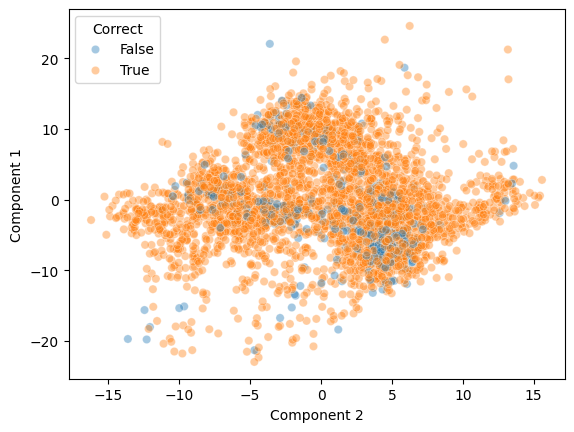

In [11]:
pca_training["Correct"] = pca_training[target_value] == training
pca_testing["Correct"] = pca_testing[target_value] == testing

sns.scatterplot(
    data = pca_testing,
    y = "Component 1",
    x = "Component 2",
    hue = "Correct",
    alpha = 0.4
)

In [12]:
from sklearn.metrics import accuracy_score

print(accuracy_score(pca_testing[target_value], pca_testing["PRED"]))
print(accuracy_score(pca_training[target_value], pca_training["PRED"]))

0.8905299739357081
0.8948016217781639


In [ ]:
# Full Code
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
#from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import accuracy_score

embeddings_finetuned_fixed = embeddings_finetuned.dropna()
embeddings_finetuned_fixed = embeddings_finetuned_fixed[labels["isSinglepurpose"]]

training_data, testing_data = train_test_split(embeddings_finetuned_fixed, test_size = 0.20, random_state = 24)

n = 40

pca = PCA(n_components = n)
scaler = StandardScaler()

# Normalization
normalized_training = scaler.fit_transform(training_data)
normalized_testing = scaler.transform(testing_data)

# PCA + Preprocessing
pca_training = pca.fit_transform(normalized_training)
pca_testing = pca.transform(normalized_testing)

pca_training = pd.DataFrame(index = training_data.index, data = pca_training, columns = [f"Component {i}" for i in range(1, n + 1)])
pca_testing = pd.DataFrame(index = testing_data.index, data = pca_testing, columns = [f"Component {i}" for i in range(1, n + 1)])

pca_training = pca_training.join(labels)
pca_testing = pca_testing.join(labels)

# MODEL - Support Vectors Machine 
svm = SVC(decision_function_shape = 'ovo')
svm.fit(pca_training[[f"Component {i}" for i in range(1, n + 1)]], pca_training[target_value])

training = svm.predict(pca_training[[f"Component {i}" for i in range(1, n + 1)]])
testing = svm.predict(pca_testing[[f"Component {i}" for i in range(1, n + 1)]])

pca_training["PRED"] = training
pca_testing["PRED"] = testing

# EVALUATION
cm = confusion_matrix(pca_training[target_value], training)
cm_dislpay = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_dislpay.plot()

cm = confusion_matrix(pca_testing[target_value], testing)
cm_dislpay = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_dislpay.plot()

print(f"Results for predicting {target_value} components")
print(accuracy_score(pca_testing[target_value], pca_testing["PRED"]))
print(accuracy_score(pca_training[target_value], pca_training["PRED"]))
print()



ValueError: Need to specify at least one of 'labels', 'index' or 'columns'

In [21]:
types, counts = np.unique(labels["MAIN_Category"], return_counts = True)

for i in range(len(types)):
    print(types[i], counts[i])
 

Antibacterial 3740
Anticancer 100
Antifungal 509
Antihypertensive 73
Antimicrobial 4916
Antioxidant 14
Antiparasitic 230
Antiviral 1460
Cell_Communication 226
Drug_delivery 73
Growth_regeneration 65
Immunoactive 27
Metabolic_regulatory 406
Multipurpose 4413
Neuropeptide 1010
Thrombolytic 3
